In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tomllib
import plt_config

# Visualizing the eigenvalues from empirical observability gramian

In [2]:
try:
    diag_values = np.load("../scripts/saved_variables/module1/diag_values_01.npy")
    eig_values = np.load("../scripts/saved_variables/module1/eig_values_01.npy")
except Exception:
    print("Run 01_Observability_Analysis.py")

In [3]:
with open("../config.toml", "rb") as f:
    cfg = tomllib.load(f)

curr_module = "01"
num_patients = cfg[curr_module]["num_patients"]
threshold = cfg[curr_module]["threshold"]
percent_states_over_threshold = (
    100 * (eig_values > threshold).sum() / len(eig_values.flatten())
)
print("Percent of eigenvalues over threshold: ", percent_states_over_threshold)

Percent of eigenvalues over threshold:  25.36


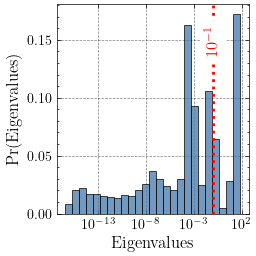

In [4]:
fig, ax = plt.subplots(figsize=(2.55, 2.55))
sns.histplot(
    eig_values.flatten(),
    stat="probability",
    bins=25,
    ax=ax,
    log_scale=True,
    legend=False,
    kde=False,
)
ax.axvline(threshold, color="red", linestyle=":", linewidth=2)
ax.text(
    threshold,
    ax.get_ylim()[1] * 0.90,
    r"$10^{-1}$",
    color="red",
    rotation=90,
    va="top",
    ha="center",
    backgroundcolor="white",
)
ax.set_xlabel("Eigenvalues")
ax.set_ylabel("Pr(Eigenvalues)")
fig.savefig("figures/5_3.pdf", format="pdf")

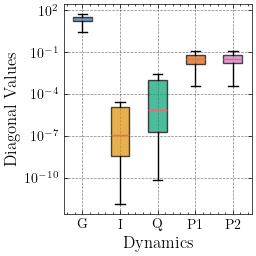

In [5]:
states = ["G", "I", "Q", "P1", "P2"]
palette = sns.color_palette("colorblind", len(states))
fig, ax = plt.subplots(figsize=(2.55, 2.55))
bp = ax.boxplot(diag_values, tick_labels=states, patch_artist=True, showfliers=False)
ax.set_yscale("log")
ax.set_xlabel("Dynamics")
ax.set_ylabel("Diagonal Values")
for patch, color in zip(bp["boxes"], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
fig.savefig("figures/5_7.pdf", format="pdf")

In [6]:
print("Medians: \n", np.percentile(diag_values, 50, axis=0))
print(
    "IQR: \n",
    np.percentile(diag_values, 75, axis=0) - np.percentile(diag_values, 25, axis=0),
)

Medians: 
 [2.22601156e+01 1.13117350e-07 6.80082370e-06 2.95305697e-02
 3.07020895e-02]
IQR: 
 [1.60889262e+01 1.12782715e-05 9.99196021e-04 4.33168715e-02
 4.35110733e-02]
